In [1]:
import matplotlib.pyplot as plt

In [2]:
x = [1, 2, 3, 4, 3, 4, 2, 4]



In [5]:
dir(plt)

['AbstractContextManager',
 'Annotation',
 'Arrow',
 'Artist',
 'AutoLocator',
 'AxLine',
 'Axes',
 'BackendFilter',
 'Button',
 'Circle',
 'Colorizer',
 'ColorizingArtist',
 'Colormap',
 'Enum',
 'ExitStack',
 'Figure',
 'FigureBase',
 'FigureCanvasBase',
 'FigureManagerBase',
 'FixedFormatter',
 'FixedLocator',
 'FormatStrFormatter',
 'Formatter',
 'FuncFormatter',
 'GridSpec',
 'IndexLocator',
 'Line2D',
 'LinearLocator',
 'Locator',
 'LogFormatter',
 'LogFormatterExponent',
 'LogFormatterMathtext',
 'LogLocator',
 'MaxNLocator',
 'MouseButton',
 'MultipleLocator',
 'Normalize',
 'NullFormatter',
 'NullLocator',
 'PolarAxes',
 'Polygon',
 'Rectangle',
 'ScalarFormatter',
 'Slider',
 'Subplot',
 'SubplotSpec',
 'TYPE_CHECKING',
 'Text',
 'TickHelper',
 'Widget',
 '_ColorizerInterface',
 '_NO_PYPLOT_NOTE',
 '_REPL_DISPLAYHOOK',
 '_ReplDisplayHook',
 '__annotations__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_a

(array([1., 2., 2., 3.]),
 array([1.  , 1.75, 2.5 , 3.25, 4.  ]),
 <BarContainer object of 4 artists>)

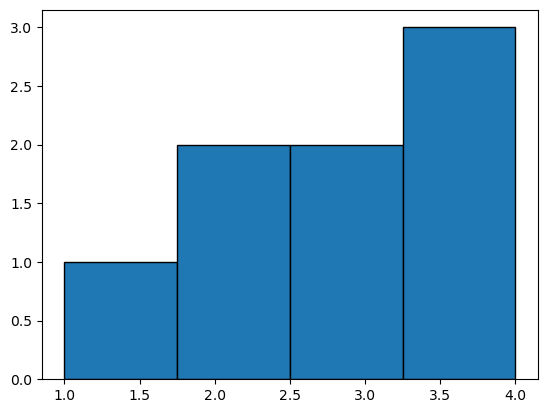

In [4]:
plt.hist(x, bins=4, edgecolor='black')

In [ ]:
%pip -q install cartopy xarray netcdf4

Note: you may need to restart the kernel to use updated packages.


In [16]:
%pip install h5netcdf

Note: you may need to restart the kernel to use updated packages.


In [22]:
%pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [24]:

import zipfile, io
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# --- Load ERA5 data ---
zip_path = '/home/chantelle/Desktop/PhD Project/code/openfast/era5_out/era5_sl_1950_01.nc'
with zipfile.ZipFile(zip_path) as zf:
    with zf.open('data_stream-oper_stepType-instant.nc') as f:
        ds = xr.open_dataset(io.BytesIO(f.read()), engine='h5netcdf')

# --- Compute mean wind speed at 100m ---
ws100 = np.sqrt(ds['u100']**2 + ds['v100']**2).mean('valid_time')

# --- Plot ---
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mesh = ax.pcolormesh(
    ws100.longitude, ws100.latitude, ws100,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    shading='auto'
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle='--')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle=':')
gl.top_labels = False
gl.right_labels = False

plt.colorbar(mesh, ax=ax, label='Mean wind speed at 100m (m/s)', shrink=0.8)
ax.set_title('ERA5 mean 100m wind speed — January 1950')
plt.tight_layout()
plt.show()


ImportError: No module named 'h5py', backend not available. Please install 'h5py' into your Python environment.